# Análisis Exploratorio de Datos

31 de Marzo de 2026

Trabajaremos **en clases** el ejemplo con la base de datos de sobrevivientes de Titanic de [Kaggle](https://www.kaggle.com/competitions/titanic). Debe responder todas las preguntas que están en el notebook (con **negrita**).



## Introducción
Antes de cualquier intento de predicciones usando algoritmos de ML, debemos tratar de entender "lo que nos dicen los datos". Para esto, realizamos un análisis de datos exploratorio (EDA en inglés). El EDA es un enfoque para analizar conjuntos de datos que busca resumir sus características principales, a menudo con métodos visuales.
Es el primer paso en cualquier análisis de datos y ayuda a descubrir patrones, detectar anomalías, probar hipótesis y verificar suposiciones. Al explorar los datos, los analistas pueden tomar decisiones informadas sobre qué variables incluir en los modelos y cómo preprocesarlas. Además, permite la selección de métodos de análisis adecuados y la formulación de preguntas de investigación relevantes.


![EDA.png](attachment:EDA.png)

## Análisis Exploratorio de Datos (EDA) con Titanic

En este notebook realizaremos una primera exploración del dataset del Titanic.

La idea **no es construir un modelo todavía**, sino aprender a:

- conocer la estructura de un conjunto de datos,
- identificar variables numéricas y categóricas,
- detectar valores faltantes,
- visualizar distribuciones,
- explorar relaciones entre variables,
- y comenzar a tomar decisiones previas al modelado.

### Pregunta guía

**¿Qué variables parecen estar asociadas con la supervivencia de los pasajeros?**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams['figure.dpi'] = 100
%matplotlib inline
sns.set_style('white')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos.
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas.
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/

### Carga del dataset

Comenzamos cargando el archivo y observando sus primeras filas.

In [ ]:
titanic=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/titanic.csv')

In [ ]:
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Descripción de las características:
- **Survived**	Sobrevivencia	0 = No, 1 = Sí
- **Pclass**	Clase	1 = primera, 2 = segunda, 3 = tercera
- **Sex**	Género
- **Age**	Edad en años (puede ser fraccional si es menos de 1)
- **Sibsp**	número de hermanas u hermanos o cónyuges
- **Parch**	número de padres/niños
- **Ticket**
- **Fare**	Tarifa
- **Cabin**	Número de la Cabina
- **Embarked**	Puerto de Embarque	C = Cherbourg, Q = Queenstown, S = Southampton


### Inspección inicial de los datos

- **¿Cuántas filas y columnas tiene el dataset?**
- **¿Qué representa cada columna?**
- **¿Qué variable podría ser nuestro objetivo?**
- **¿Qué tipos de datos tenemos?**

<details>
<summary>Ayuda</summary>

Las siguientes funciones de `pandas` pueden ser útiles
- df.shape
- df.info()
- df.describe(include="all")

</details>

### Preguntas para pensar

1. **¿Cuál parece ser la variable objetivo en este problema?**
2. **¿Qué variables son numéricas?**
3. **¿Qué variables son categóricas?**
4. **¿Qué columnas parecen más difíciles de usar directamente en un modelo?**


**Respuesta acá**

In [ ]:
dimensiones=titanic.shape
print('El dataset posee', dimensiones[0],'filas y', dimensiones[1], 'columnas.')

El dataset posee 891 filas y 12 columnas.


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Cada columna representa un dato distinto sobre los pasajeros del titanic, si sobrevivió, la clase en la que viajo, nombre, sexo, edad, número de hermanos/as y/o esposo/a, número de padres y/o hijos/as, el número del ticket, el precio que pagaron, número de la cabina y donde embarcaron.

En su mayoría tenemos datos que clasifican a los pasajeros (strings de texto), y algunos datos numericos (int y floats).

Nuestra variable objetivo podría ser si sobrivió o no en relación a su genero, clase en la que viajo, etc. y así al conocer su relación respecto a los otros datos, podremos hacer que el modelo aprenda a predecir si un pasajero del titanic con ciertas caracteristicas habría sobrevivido o no.

Las variables númericas son:

* Age
* Fare
* SibSp
* Parch

Las variables categoricas son:
* Survived
* Pclass
* Sex
* Ticket
* Cabin
* Embarked

Las variables más dificiles de usar son:
* Name: Cada nombre es único y carece de relación lógica respecto a las otras variables, requeriría mucha creatividad y trabajo el arreglar los datos para que sean viables en el uso del entrenamiento de los modelos.
* Ticket: Sufre los mismos problemas que la variable 'Name', ya que habría que analizar el significado de la parte literal y númerica para poder entender si tienen alguna relación lógica respecto al resto de variables.
* Cabin: En este caso la caracteristica presenta muchos datos nulos, esto hace que los resultados que puedan ser obtenidos con esta variable no sean confiables y puede requerir que se utilicen metodos para rellenar los datos faltantes.

### Valores faltantes

Uno de los primeros pasos de un EDA es revisar si faltan datos.

Los valores faltantes pueden afectar tanto el análisis como el entrenamiento de modelos, por lo que es importante detectarlos desde el comienzo.

**Revise las columnas, la cantidad de filas, cuáles columnas tiene datos faltantes, y cuántos datos faltan por cada columna**

<details>
<summary>Ayuda</summary>

```python
titanic['nombrecolumna'].notna().sum()
```
</details>

**Preguntas**
- **¿Qué variable parece más problemática?**
- **¿Cuál podríamos eliminar?**
- **¿Cuál valdría la pena conservar?**

In [ ]:
print('Número de filas:',len(titanic))

a = 0
headers=titanic.columns

for i in range(len(headers)):
  a = titanic[headers[i]].isnull().sum()
  print('El total de datos faltantes/nulos en la variable', headers[i], 'es:', a)
  a = 0

Número de filas: 891
El total de datos faltantes/nulos en la variable PassengerId es: 0
El total de datos faltantes/nulos en la variable Survived es: 0
El total de datos faltantes/nulos en la variable Pclass es: 0
El total de datos faltantes/nulos en la variable Name es: 0
El total de datos faltantes/nulos en la variable Sex es: 0
El total de datos faltantes/nulos en la variable Age es: 177
El total de datos faltantes/nulos en la variable SibSp es: 0
El total de datos faltantes/nulos en la variable Parch es: 0
El total de datos faltantes/nulos en la variable Ticket es: 0
El total de datos faltantes/nulos en la variable Fare es: 0
El total de datos faltantes/nulos en la variable Cabin es: 687
El total de datos faltantes/nulos en la variable Embarked es: 2


In [ ]:
2/891*100

0.22446689113355783

Las columnas que presentan datos faltantes son:

* Age: 177
* Cabin: 687
* Embarked: 2

Y la cantidad total de filas es 891

De las 3 variables, la más problematica es 'Cabin', ya que solo se tienen 204 datos disponibles, del total de 891, lo cuál es solo un ~23% del total de datos, esto hace que los resultados obtenidos con este no sean confiables, e incluso el tratar de rellenar los datos puede producir mayor desconfiabilidad, además de requerir gran cantidad de trabajo para que los datos tengan una interpretación lógica, por lo que puede resultar más conveniente eliminarla.

Las variables 'Age' si bien presenta 177 datos faltantes, esto solo representa un ~20% de los datos, por lo que las conclusiones que se obtengan al trabajar con los datos no deberían verse mayormente afectadas, incluso en este caso el tratar de rellenar los datos utilizando valores que sigan alguna distribución obtenida de los datos existentes es más confiable ya que la cantidad de datos a obtener es mucho menor a los del caso de la variable 'Cabin' y tambien es más fácil ya que es una variable númerica y continua.

Y por último la variable 'Embarked' solo tiene 2 datos faltantes por lo que el rellenarlos de manera aleatoria o según alguna distribución, produciría el mismo efecto que no hacer nada respecto a esto, ya que 2 datos no representa ni siquiera el 1% de la muestra (0.22% para ser exactos) por lo que se puede trabajar con ella sin mayor preocupación.


## El primer paso es caracterizar la muestra, es decir, responder la pregunta: **¿quiénes eran los pasajeros del titanic?**

Haremos análisis de las variables  categóricas del set de datos para caracterizar a los pasajeros

La función [`catplot`](https://seaborn.pydata.org/generated/seaborn.catplot.html) de seaborn  sirve para graficar variables categóricas (con etiquetas).

Para contabilizar la variable categórica 'Sex'

In [ ]:
titanic['Sex'].value_counts()

,count
Sex,
male,577
female,314


**Explore el resto de las variables categóricas del dataset**

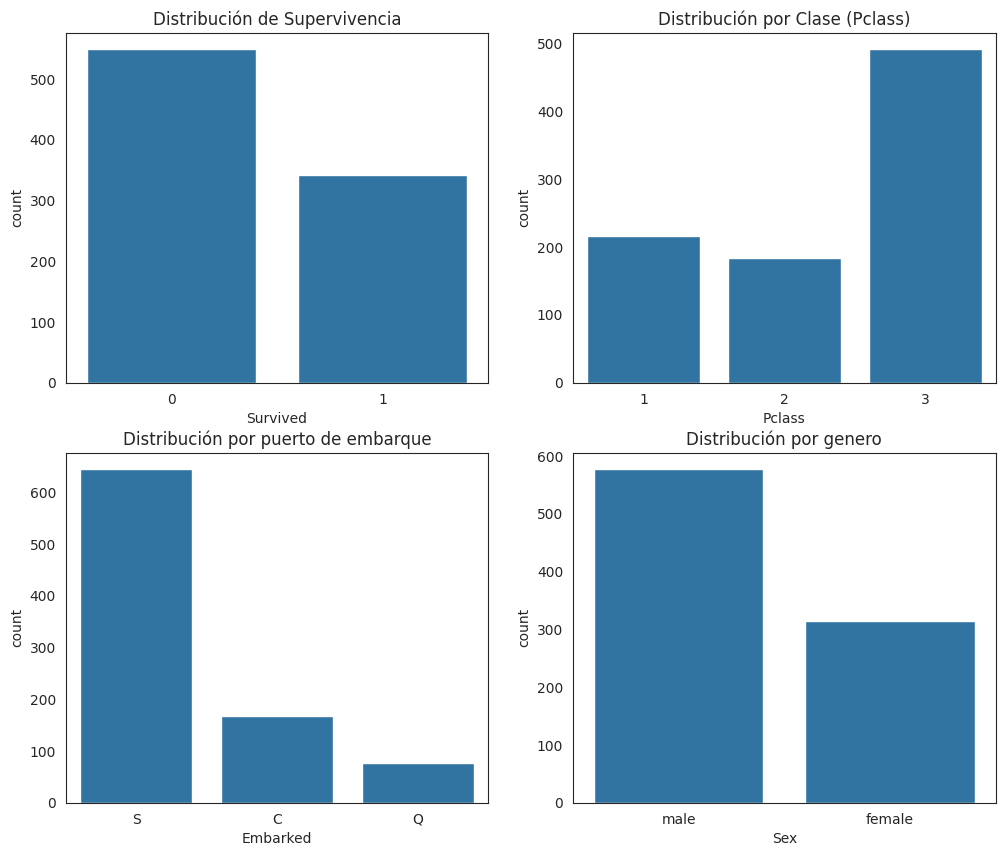

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(x='Survived', data=titanic, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de Supervivencia')

sns.countplot(x='Pclass', data=titanic, ax=axes[0, 1])
axes[0, 1].set_title('Distribución por Clase (Pclass)')

sns.countplot(x='Embarked', data=titanic, ax=axes[1, 0])
axes[1, 0].set_title('Distribución por puerto de embarque')

sns.countplot(x='Sex', data=titanic, ax=axes[1, 1])
axes[1, 1].set_title('Distribución por genero')

plt.show()

Recuerde graficar la variable target, que nos interesaría predecir con un modelo de ML

**Preguntas**
- **¿Hay categorías con muy pocos casos?**
- **¿Hay alguna variable claramente desbalanceada?**
- **¿Esto podría influir en el análisis posterior?**

<p align= "justify">
Respecto a la cantidad de casos, para los puertos donde se embarcaron los pasajeros del Titanic, las categorias C y Q presentan una cantidad de datos muy pequeña, de 168 y 77 respectivamente. Tambien las categorias de Pclass 1 y 2 presentan una cantida un poco reducida de datos 216, 184 respectivamente, si bien no son valores tan pequeños como los mencionados anteriormente es bueno tener ese factor en cuenta.

<p align= "justify">
Al observar las variables podemos detectar que todas presentan un desbalance respecto a las cantidades bastante claro, los casos más claros siendo el puerto de embarque, donde el puerto S corresponde al ~70% de los datos y el Pclass, donde los pasajeros de 3ra clase representan el ~55% de la muestra. Y para las variables de sexo y supervivencia es visible que una variable es casi el doble de la otra en tamaño.

Esto podría entonces influir en el análisis posterior debido a las siguientes razones:

<p align= "justify">
Bias: Por ejemplo si en los datos que le entregamos al modelo se observa que la mayoría de los pasajeros hombres murieron, este podría "aprender" a predecir que "si es hombre entonces no sobrevivió", por lo que ignoraría los casos de los hombres que si sobrevivieron ya que estos son la minoría.


<p align= "justify">
Accuracy: Si nuestros datos mostraran que el 90% de los pasajeros mueren, entonces nuestro modelo sería capaz de obtener un 90% de precisión al predecir que un sujeto muerte, lo cuál lo haría inutil ya que no sabría identificar a los sobrevivientes.

<p align= "justify">
Dificultad de generalización: Por ejemplo para los casos del puerto donde se embarcó, debido a la poca cantidad de casos para los puertos C y Q el modelo solo sería valido para los pasajeros del puerto S.


Ahora veremos las variables numéricas del dataset. Primero entenderemos la variable `Age`. Nos interesa detectar forma de la distribución, posible asimetría (skewness), presencia de outliers y valores faltantes

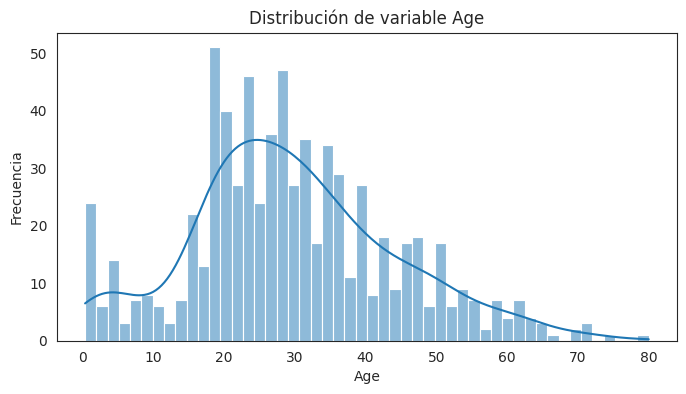

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(titanic["Age"], bins=50, kde=True)
plt.title("Distribución de variable Age")
plt.xlabel("Age")
plt.ylabel("Frecuencia")
plt.show()

### Preguntas para discutir

- **¿La distribución parece simétrica?**
- **¿Hay edades extremas?**
- **Si debemos imputar esta variable, ¿usarías media o mediana?**

**Respuestas acá**

<p align='justify'>
Como podemos ver, tenemos una distribución asimétrica, que presenta un right skewness, el cual se puede distinguir por la cola extendida que tiene al lado derecho. Esta es causada por las edades extremas que se observan en la cola, desde 60 a 80 años.

<p align='justify'>
Si deseamos rellenar entonces los datos faltantes de la muestra, se debería hacer uso de la mediana, ya que los valores extremos producen que la media, en este caso, se mueva hacia la derecha, por lo que no representaría al pasajero típico, por el contrario, la meadiana no introduce el error de los valores extremos por lo tanto nos permitiría obtener valores que preserven la distribución y no deformen la curva.


**Repita el análisis para el resto de las variables numéricas**

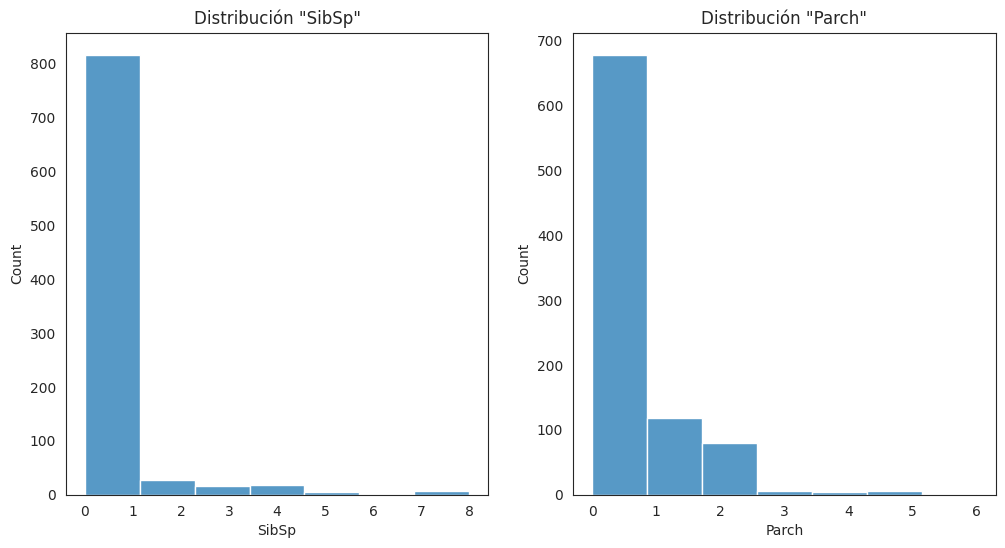

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.histplot(titanic['SibSp'], ax=axes[0], bins=7)
axes[0].set_title('Distribución "SibSp"')


sns.histplot(titanic['Parch'], ax=axes[1], bins=7)
axes[1].set_title('Distribución "Parch"')

plt.show()


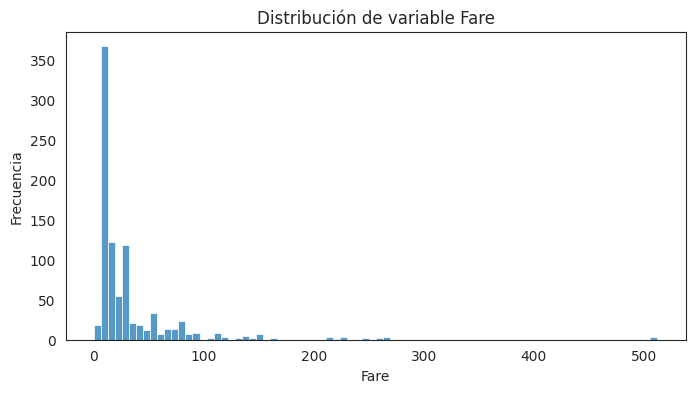

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(titanic["Fare"], bins=80)
plt.title("Distribución de variable Fare")
plt.xlabel("Fare")
plt.ylabel("Frecuencia")
plt.show()

**Preguntas:**
- **¿La variable `Fare` parece sesgada?**
- **¿Hay outliers?**
- **¿Podría ser útil aplicar una transformación en etapas posteriores?**

<p align='justify'>
Al igual que en la variable 'Age', la variable 'Fare' está right skewed, esto se puede determinar al ver la larga cola de datos que presenta hacia su lado derecho, por lo que al igual que en el caso anterior, la media no será una medida confiable y en este caso en particular estará mucho más alejada de la mediana que en el caso de la edad de los pasajeros.

<p align='justify'>
Podemos observar que los datos presentan muchos outliers, englobando todos los datos que son mayores a 100, especialmente esos valores que se encuentran alrededor de 500.

<p align='justify'>
El aplicar una transformación, por ejemplo una transformación logaritmica, nos permitiría reducir el rango de los datos, acercando los valores extremos más al centro, normalizando la distribución observada, lo cual es útil para reducir el efecto que los outliers tendrían al momento de entrenar los modelos.

### Análisis Bivariado

Ahora revisaremos las relaciones entre la variable `Survived` y otras variables

Comparemos la proporción de supervivencia respecto a la variable `Sex`

<Figure size 600x400 with 0 Axes>

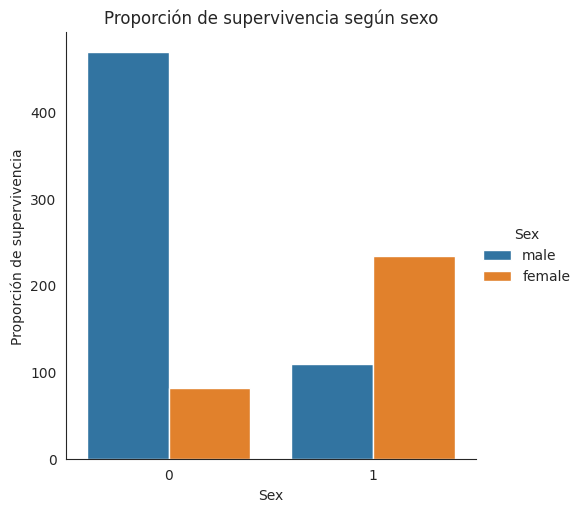

In [ ]:
plt.figure(figsize=(6,4))
sns.catplot(data=titanic, x="Survived", hue="Sex", kind="count")
plt.title("Proporción de supervivencia según sexo")
plt.xlabel("Sex")
plt.ylabel("Proporción de supervivencia")
plt.show()

<Figure size 1000x600 with 0 Axes>

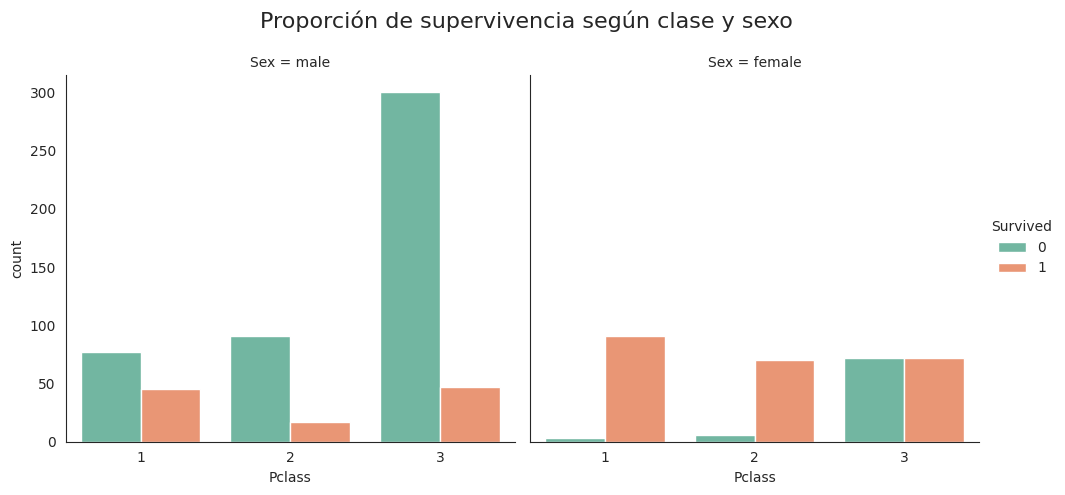

In [ ]:
plt.figure(figsize=(10, 6))

sns.catplot(x='Pclass', hue='Survived', col='Sex', data=titanic, kind='count',palette='Set2')
plt.suptitle('Proporción de supervivencia según clase y sexo', fontsize=16)
plt.subplots_adjust(top=0.85)

plt.show()

<Figure size 1000x600 with 0 Axes>

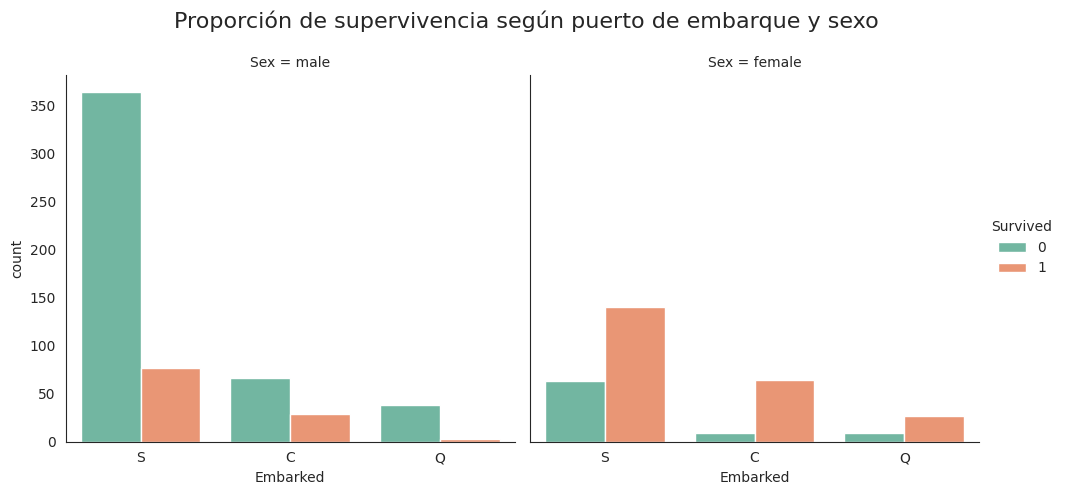

In [ ]:
plt.figure(figsize=(10, 6))

sns.catplot(x='Embarked', hue='Survived', col='Sex', data=titanic, kind='count',palette='Set2')
plt.suptitle('Proporción de supervivencia según puerto de embarque y sexo', fontsize=16)
plt.subplots_adjust(top=0.85)

plt.show()

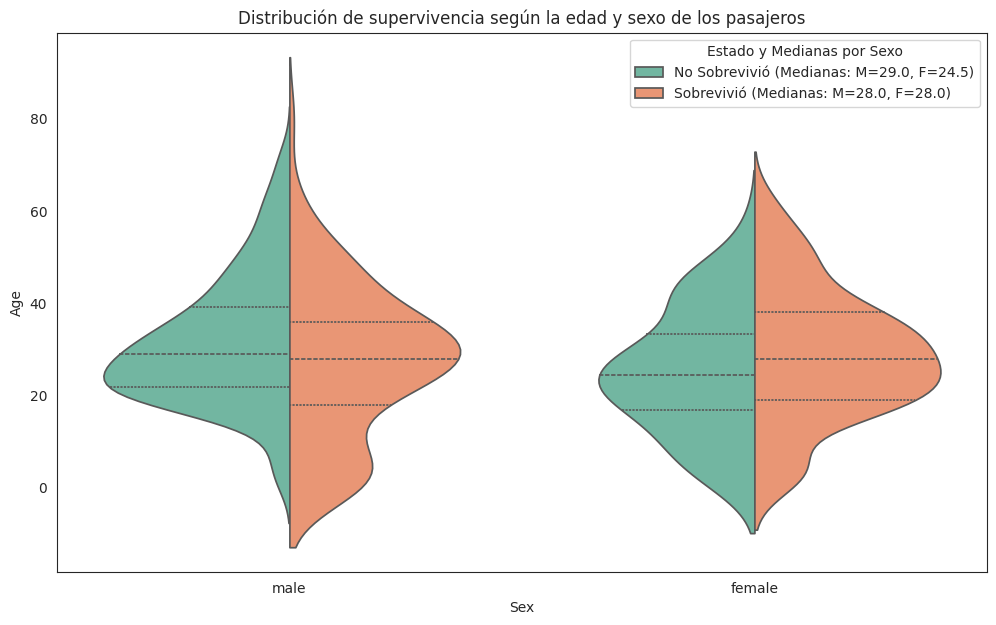

In [ ]:
m = titanic.groupby(['Sex', 'Survived'])['Age'].median()

label_no = f'No Sobrevivió (Medianas: M={m["male", 0]:.1f}, F={m["female", 0]:.1f})'
label_si = f'Sobrevivió (Medianas: M={m["male", 1]:.1f}, F={m["female", 1]:.1f})'

plt.figure(figsize=(12, 7))

ax = sns.violinplot(x='Sex', y='Age', hue='Survived', data=titanic,
                   split=True, inner="quart", palette='Set2')

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, [label_no, label_si], title='Estado y Medianas por Sexo', loc='upper right')

plt.title('Distribución de supervivencia según la edad y sexo de los pasajeros')
plt.show()


Este gráfico permite comparar la fracción promedio de pasajeros que sobrevivieron en cada categoría.

### Preguntas

- **¿Parece haber una diferencia importante?**
- **¿Esto implica causalidad?**
- **¿Qué otras variables podrían estar influyendo también?**

**Respuesta acá**

Se pueden observar las siguientes diferencias en los gráficos:

Supervivencia por Sexo: Se observa que la gran mayoría de los hombres no sobrevivió, mientras que la mayoría de las mujeres sí lo hizo.

Distribución por Edad: El gráfico muestra que, aunque las medianas de edad son similares (alrededor de los 28-29 años), la "forma" de la supervivencia en hombres tiene un pico en edades muy tempranas (niños).

Clase Social: El gráfico de Pclass muestra que en la 3ra clase, la cantidad de hombres que no sobrevivieron es masiva en comparación con cualquier otra categoría.

Puerto de Embarque: Podemos ver que los hombres que embarcaron en Southampton representan una gran parte de los pasajeros que no sobrevivieron.

---

Estos resultados por si solos no indican causalidad, ya que "correlación no implica causalidad". Así que aunque exisra una relación estadística entre el ser mujer y sobrevivir, la causa real no es el sexo en sí mismo, sinó el protocolo de la epoca para el acceso a los botes "mujeres y niños primero".

---

Otras variables que pueden afectar a la supervivencia son:

Presencia de Familia (SibSp / Parch): Tener hijos o padres a bordo solía influir en si una persona se quedaba buscando a su familia o subía de inmediato a un bote.

Edad (Niños): Los niños varones tuvieron una tasa de supervivencia distinta a la de los hombres adultos, lo que indica que la edad interactúa con la supervivencia.

Incluso podemos hacer el mismo análisis pero comparar interacciones entre variables, por ejemplo `Sex` y `P_class`

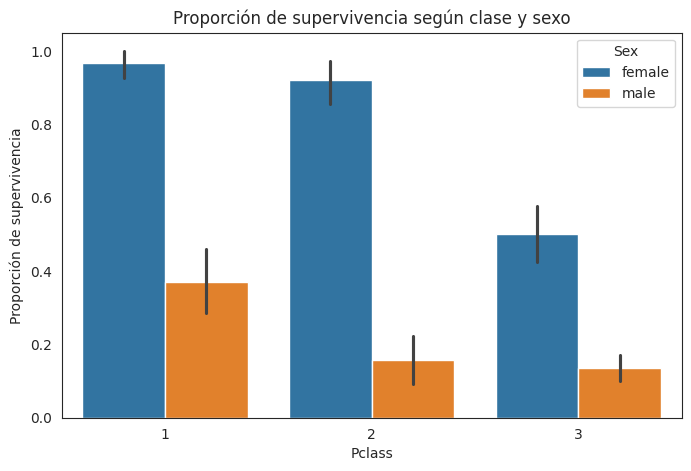

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=titanic, x="Pclass", y="Survived", hue="Sex", estimator=np.mean)
plt.title("Proporción de supervivencia según clase y sexo")
plt.xlabel("Pclass")
plt.ylabel("Proporción de supervivencia")
plt.show()

- **¿Sigue siendo importante el sexo dentro de cada clase?**
- **¿Sigue siendo importante la clase dentro de cada sexo?**
- **¿Qué nos dice esto sobre la interacción entre variables?**

**Compare otras variables con la supervivencia (edad, clase, tarifa, etc) y resuma sus observaciones**

El sexo mantiene su relevancia en todos los niveles. Al segmentar los datos por clase (Pclass), se evidencia que la brecha de supervivencia entre hombres y mujeres se conserva. Ya que en todos los gráficos se puede observar una clara

---
La clase social ejerce un impacto directo dentro de cada género. Para el grupo femenino, viajar en primera o segunda clase aseguraba una supervivencia casi total; sin embargo, en tercera clase, la probabilidad de sobrevivir cae drásticamente a la mitad (aprox. 50%).

---

El análisis conjunto de los datos demuestra que existe un efecto de interacción. Esto significa que no podemos explicar el impacto de la clase social o del género por separado, ya que el efecto de una variable depende por completo de la otra.

El ejemplo más claro de esto se ve en la segunda clase: aquí el protocolo de "mujeres y niños primero" se cumplió de forma drástica. Esto permitió que las mujeres de segunda clase tuvieran una supervivencia casi tan alta como las de primera, pero al mismo tiempo condenó a los hombres de esta categoría a una tasa de mortalidad tan baja como la de tercera clase.

### Correlación entre variables numéricas

La matriz de correlación puede servir para detectar relaciones lineales entre variables numéricas.



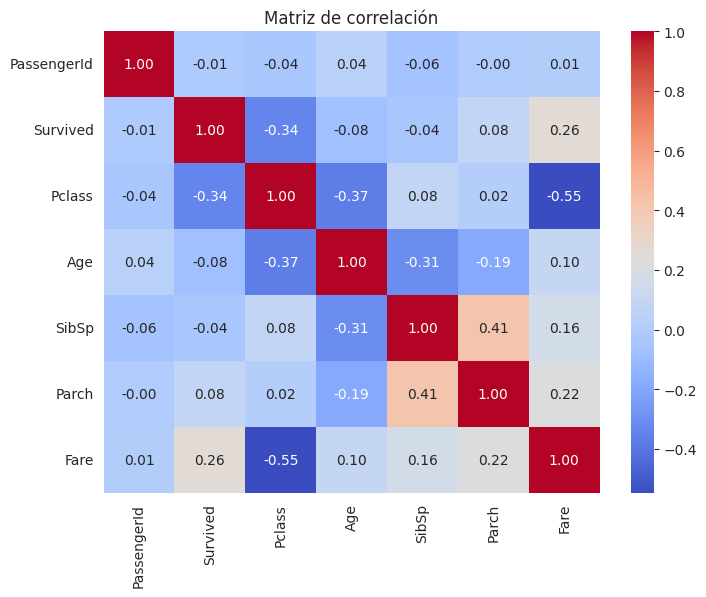

In [ ]:
corr = titanic.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

**Cuidado al interpretar!!**

- La correlación de Pearson mide relaciones lineales.
- Una correlación baja no implica que una variable no sea útil.
- `Survived` es binaria, así que esta matriz debe interpretarse con precaución.

## No toda visualización es igual de útil

A veces un gráfico puede hacerse, pero eso no significa que sea la mejor opción para interpretar una relación.

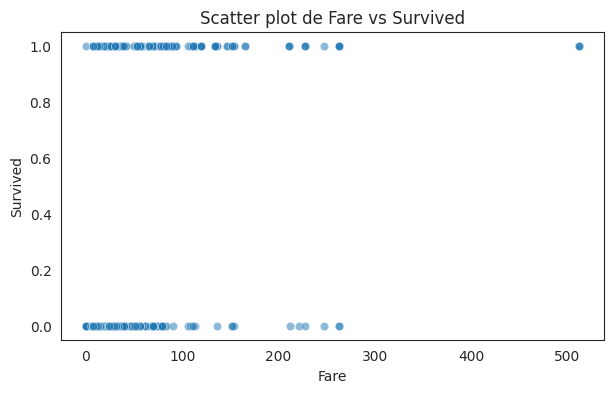

In [ ]:
plt.figure(figsize=(7,4))
sns.scatterplot(data=titanic, x="Fare", y="Survived", alpha=0.5)
plt.title("Scatter plot de Fare vs Survived")
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.show()

**Pregunta**

**¿Te parece que este gráfico ayuda realmente a entender la relación entre ambas variables? ¿Por qué podría no ser la mejor opción?**

Este gráfico no es útil, un gráfico de dispersión (scatter plot) no funciona bien cuando una de las variables es binaria (Survived solo vale 0 o 1). Esto genera dos problemas principales:

 * Saturación de puntos (Overplotting): Como la gran mayoría de los pasajeros pagó tarifas bajas, cientos de puntos se enciman uno sobre otro en la base del gráfico. Esto hace imposible ver la verdadera densidad o cantidad de datos en esa zona.

 * Oculta la tendencia: No permite ver de forma clara si una tarifa más alta aumentaba las probabilidades de sobrevivir.

Mejores alternativas: Un boxplot o un histograma superpuesto dividiendo los datos entre sobrevivientes y no sobrevivientes. Esto permitiría observar mejor si existe una relación entre las variables, ya que nos darían una vista más clara de los datos.

Hay dos variables que no analizamos: SibSp y Parch.
¿Qué creen que representan?

In [ ]:
titanic[['SibSp','Parch']].describe()

,SibSp,Parch
count,891.000000,891.000000
mean,0.523008,0.381594
std,1.102743,0.806057
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.000000,0.000000
max,8.000000,6.000000


Ambas variables cuantifican los lazos familiares de cada pasajero a bordo:

SibSp (Siblings / Spouses): El número de hermanos, hermanas o cónyuges (esposo/a) que acompañaban al pasajero.

Parch (Parents / Children): El número de padres, madres o hijos/as que viajaban con el pasajero.

Grafique la relación entre ambas variables y Survived


/tmp/ipykernel_1995/3236900988.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='SibSp', y='Survived', ax=axes[0], errorbar=None, palette='viridis')
/tmp/ipykernel_1995/3236900988.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='Parch', y='Survived', ax=axes[1], errorbar=None, palette='viridis')


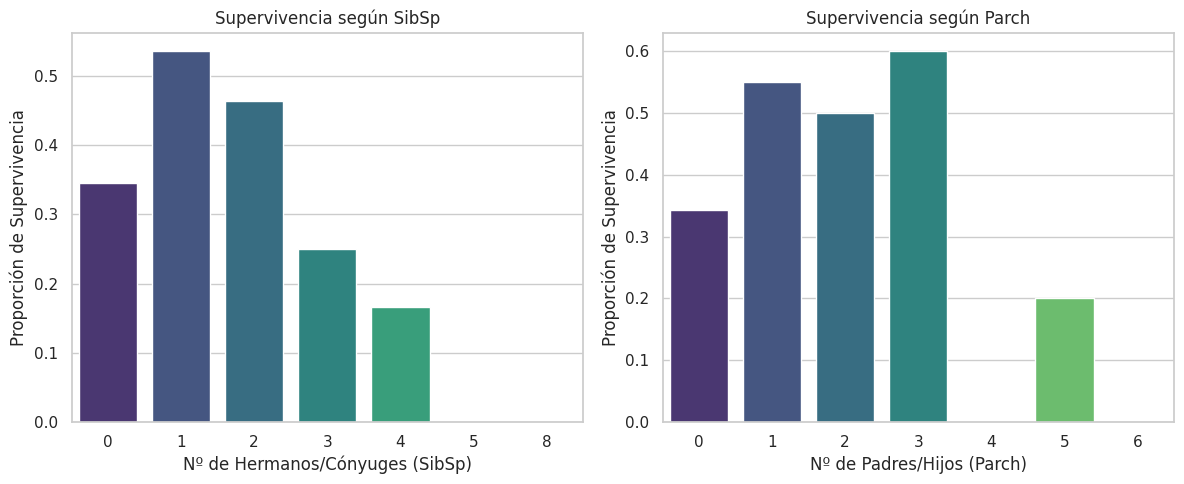

In [ ]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para SibSp
sns.barplot(data=titanic, x='SibSp', y='Survived', ax=axes[0], errorbar=None, palette='viridis')
axes[0].set_title('Supervivencia según SibSp')
axes[0].set_xlabel('Nº de Hermanos/Cónyuges (SibSp)')
axes[0].set_ylabel('Proporción de Supervivencia')

# Gráfico para Parch
sns.barplot(data=titanic, x='Parch', y='Survived', ax=axes[1], errorbar=None, palette='viridis')
axes[1].set_title('Supervivencia según Parch')
axes[1].set_xlabel('Nº de Padres/Hijos (Parch)')
axes[1].set_ylabel('Proporción de Supervivencia')

plt.tight_layout()
plt.show()

- **¿tiene sentido usarlas tal cual?**
- **¿son fáciles de interpretar?**
- **¿qué problema ven?**

¿Les parece más útil tener dos variables…
o una que represente tamaño de familia?

Cree una nueva variable que use la información de estas otras dos y represente mejor la información. Grafique la relación de esta variable con Survived

Aunque son fáciles de interpretar a nivel individual, presentan los siguientes problemas en el análisis:

* Dispersión de la información: Fragmentan un único concepto clave, si el pasajero viajaba solo o acompañado, y qué tan grande era su núcleo familiar.

* Sesgo de distribución: Como muestra el comando .describe(), más del 50% de los datos en ambas variables es $0$ (el pasajero viajaba solo). Analizarlas por separado genera gráficos redundantes con barras muy concentradas en el cero y datos muy dispersos en los valores altos (como el máximo de 8 o 6 familiares).
---

Es mucho más útil consolidarlas en una sola variable de "Tamaño de Familia". Al sumarlas, reducimos la dimensionalidad del dataset, simplificamos la interpretación de los gráficos y capturamos mejor el fenómeno social (las familias grandes solían tener más dificultades para coordinarse y acceder juntas a los botes, mientras que los pasajeros solitarios o con un solo acompañante tenían dinámicas distintas).

/tmp/ipykernel_1995/3852802290.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=titanic, x='FamilySize', y='Survived', ci=None, palette='Blues_d')
/tmp/ipykernel_1995/3852802290.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='FamilySize', y='Survived', ci=None, palette='Blues_d')


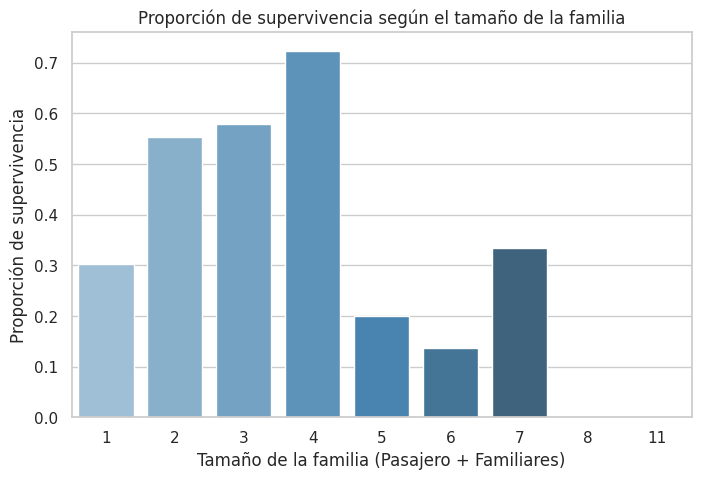

In [ ]:
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1

# 2. Graficar la relación con Survived
plt.figure(figsize=(8, 5))
sns.barplot(data=titanic, x='FamilySize', y='Survived', ci=None, palette='Blues_d')

plt.title('Proporción de supervivencia según el tamaño de la familia')
plt.xlabel('Tamaño de la familia (Pasajero + Familiares)')
plt.ylabel('Proporción de supervivencia')
plt.show()

## Conclusión

El EDA no consiste solo en visualizar datos.
El objetivo es **entender los datos y tomar decisiones informadas antes del modelado**.

A lo largo de este análisis exploratorio del dataset del Titanic, logramos construir una comprensión profunda de los datos antes de acercarnos a cualquier modelo predictivo. Las principales conclusiones que guiarán el modelado son:

Sobre la estructura de los datos: El dataset contiene variables de distinta naturaleza — numéricas continuas, categóricas y binarias — lo que exigirá preprocesamiento diferenciado. Las columnas `Cabin` (77% de valores nulos) y `Name` son candidatas claras a ser eliminadas, mientras que `Age` puede imputarse con la mediana debido a su distribución asimétrica.

Sobre los factores asociados a la supervivencia: El análisis bivariado reveló que las variables más relevantes para predecir sobrevivencia son:

 * `Sex`: Las mujeres sobrevivieron en una proporción muy superior a los hombres, reflejando el protocolo "mujeres y niños primero".
 * `Pclass`: La clase social tuvo un impacto directo; los pasajeros de 1ra clase tuvieron tasas de supervivencia significativamente mayores.
 * `Age`: Los niños varones mostraron patrones distintos al resto de los hombres.
 * `FamilySize`: La variable construida a partir de SibSp y Parch permite capturar mejor el efecto del grupo familiar que las dos variables por separado.

Sobre las interacciones entre variables: Uno de los hallazgos más importantes es que las variables no actúan de forma independiente. El género y la clase social interactúan: ser mujer de 2da clase garantizaba casi la misma supervivencia que ser de 1ra clase, mientras que los hombres de 2da clase tuvieron tasas similares a los de 3ra. Esto anticipa que un modelo simple puede no ser suficiente.

En definitiva, el EDA nos permitió pasar de un conjunto de columnas sin contexto a una comprensión clara de quiénes eran los pasajeros, qué variables importan, cómo se relacionan entre sí y qué transformaciones serán necesarias.

